# Concurvity: hydro generation and power price

**Concurvity** is what multicollinearity is called when the shared variance comes from a smooth
function of time rather than a straight line. It shows up whenever a model sees both an
explicit seasonality term and a raw feature that happens to have its own seasonal cycle.

Take day-ahead power price. Winter heating demand drives it up every year — that's a real,
calendar-locked effect. Hydro generation also swings every year, peaking with spring snowmelt,
for reasons that have nothing to do with heating demand. Feed a model both the calendar and raw
hydro output, and it cannot tell "this is winter" from "this is a low-hydro month" — both show
up as the same seasonal wobble. A regulatory change, an earlier snowmelt, a new dam upstream —
anything that shifts *when* hydro peaks relative to the calendar breaks that borrowed
correlation, and a model that quietly leaned on it mispredicts.

**Claim:** replace raw hydro output with its anomaly against a seasonal normal
(`hydro_anomaly = hydro_gw - climatology(hydro_gw)`) and the model no longer needs to guess
which feature owns the shared variance. We test that on simulated data with a known answer.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

RNG = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
PURPLE, GREEN = "#8172B2", "#55A868"  # raw feature / anomaly feature, used throughout

## The data

12 years, daily. Winter demand drives price and never changes. Hydro output has its own
seasonal cycle (snowmelt) plus a slow, persistent wet/dry anomaly (AR(1) — a wet spell stays
wet for weeks) that genuinely moves price through the merit order: more cheap hydro, lower
price. **Price never depends on hydro's seasonal shape, only on its anomaly.**

4 years of history feed the first climatology estimate; models are trained on the next 5
years; the last 3 years are held out. At the test boundary, a new environmental-flow rule
delays reservoir releases, so hydro's seasonal peak shifts ~4 months later in the year — a
plausible, discrete regime change. Nothing about winter demand's seasonality moves.

train: 2016-01-01 -> 2020-12-31 (1827d)   test: 2021-01-01 -> 2023-12-31 (1095d)


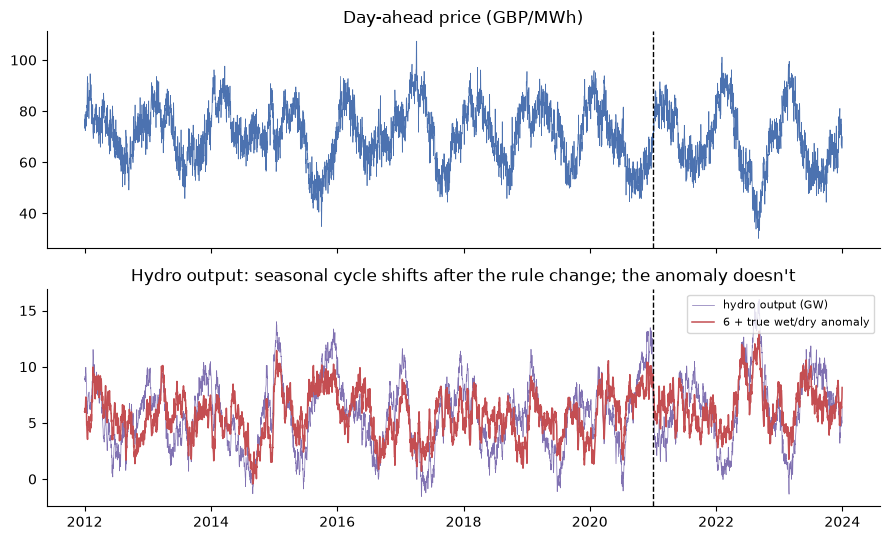

In [2]:
n_years, burn_in_years, train_years = 12, 4, 5
shift_year = burn_in_years + train_years
n_days = int(n_years * 365.25)
dates = pd.date_range("2012-01-01", periods=n_days, freq="D")
t_years = (dates - dates[0]).days / 365.25
shift_mask = t_years >= shift_year

demand_effect = 12 * np.sin(2 * np.pi * t_years) + 6 * np.cos(2 * np.pi * t_years)  # GBP/MWh

phase_pre, phase_post = 0.30, 0.60  # environmental-flow rule delays the release schedule
phase = np.where(shift_mask, phase_post, phase_pre)
hydro_seasonal = 3.0 * np.sin(2 * np.pi * (t_years + phase))  # GW

rho, sigma_innov = 0.97, 0.5
hydro_anomaly_true = np.empty(n_days)
hydro_anomaly_true[0] = 0.0
innov = RNG.normal(0, sigma_innov, n_days)
for i in range(1, n_days):
    hydro_anomaly_true[i] = rho * hydro_anomaly_true[i - 1] + innov[i]

hydro_gw = 6.0 + hydro_seasonal + hydro_anomaly_true + RNG.normal(0, 0.2, n_days)

beta_anom, intercept, sigma_y = -3.0, 70.0, 4.0  # GBP/MWh per GW; baseline price; noise
price = intercept + demand_effect + beta_anom * hydro_anomaly_true + RNG.normal(0, sigma_y, n_days)

df = pd.DataFrame({"t_years": t_years, "hydro_gw": hydro_gw, "hydro_seasonal": hydro_seasonal,
                    "hydro_anomaly_true": hydro_anomaly_true, "price": price}, index=dates)
df["doy"], df["year"] = df.index.dayofyear, df.index.year
fourier_cols = ["sin1", "cos1", "sin2", "cos2"]
for i in [1, 2]:
    df[f"sin{i}"] = np.sin(2 * np.pi * i * df["t_years"])
    df[f"cos{i}"] = np.cos(2 * np.pi * i * df["t_years"])

train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)].copy()
test = df[df["t_years"] >= shift_year].copy()
print(f"train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)}d)   "
      f"test: {test.index.min().date()} -> {test.index.max().date()} ({len(test)}d)")

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5.5))
axes[0].plot(df.index, df["price"], lw=0.5, color="#4C72B0")
axes[0].set_title("Day-ahead price (GBP/MWh)")
axes[1].plot(df.index, df["hydro_gw"], lw=0.5, color=PURPLE, label="hydro output (GW)")
axes[1].plot(df.index, 6 + df["hydro_anomaly_true"], lw=1.1, color="#C44E52", label="6 + true wet/dry anomaly")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].set_title("Hydro output: seasonal cycle shifts after the rule change; the anomaly doesn't")
for ax in axes:
    ax.axvline(test.index.min(), color="k", ls="--", lw=1)
fig.tight_layout()
plt.show()

## Features and diagnostics

Two Fourier harmonics of the calendar (identical in every model), plus either raw hydro output
or its anomaly against a climatology. The climatology is refit every year from prior years
only (causal, no leakage) as a smooth Fourier regression — realistic, and far less noisy than a
raw day-of-year average.

In [3]:
def build_anomaly_feature(frame):
    frame = frame.copy()
    frame["climatology"] = np.nan
    for i, yr in enumerate(sorted(frame["year"].unique())):
        if i == 0:
            continue
        hist = frame[frame["year"] < yr]
        clim = LinearRegression().fit(hist[fourier_cols], hist["hydro_gw"])
        mask = frame["year"] == yr
        frame.loc[mask, "climatology"] = clim.predict(frame.loc[mask, fourier_cols])
    frame["climatology"] = frame["climatology"].bfill()
    frame["hydro_anomaly"] = frame["hydro_gw"] - frame["climatology"]
    return frame

df = build_anomaly_feature(df)
train = df[(df["t_years"] >= burn_in_years) & (df["t_years"] < shift_year)].copy()
test = df[df["t_years"] >= shift_year].copy()
features_raw, features_anom = fourier_cols + ["hydro_gw"], fourier_cols + ["hydro_anomaly"]

def vif_table(frame, cols):
    X = frame[cols].to_numpy()
    return pd.Series([variance_inflation_factor(X, i) for i in range(X.shape[1])], index=cols)

diag = pd.DataFrame({
    "VIF (raw model)": vif_table(train, features_raw).reindex(fourier_cols + ["hydro_gw"]).values,
    "VIF (anomaly model)": vif_table(train, features_anom).reindex(fourier_cols + ["hydro_anomaly"]).values,
}, index=fourier_cols + ["X"])
print(diag.round(2))

      VIF (raw model)  VIF (anomaly model)
sin1             1.05                 1.02
cos1             2.16                 1.01
sin2             1.00                 1.00
cos2             1.01                 1.02
X                2.22                 1.05


`hydro_gw` picks up real VIF against the seasonality terms; the anomaly is close to
decorrelated from them, by construction.

## Models and coefficient recovery

ElasticNet (standardized, 5-fold CV) and XGBoost, each fit once on raw hydro output and once
on the anomaly. Compare the recovered coefficients against the true generating values.

      true value  raw model  anomaly model
sin1        12.0       9.23           9.73
cos1         6.0      14.45           4.88
sin2         0.0       0.00          -0.34
cos2         0.0       0.14          -0.08
X           -3.0      -3.02          -2.88


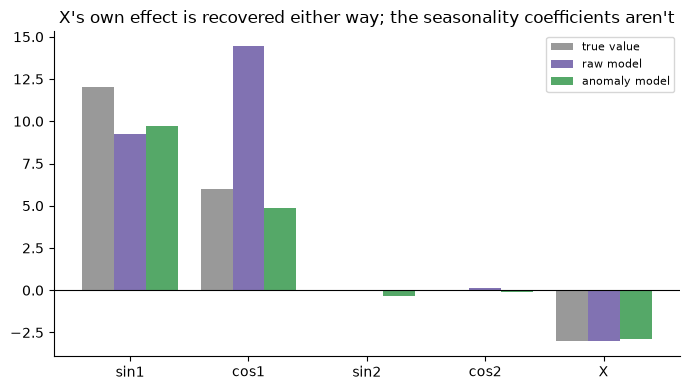

In [4]:
def fit_enet(train_df, cols):
    m = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .9, 1], cv=5, random_state=0, max_iter=10000))
    return m.fit(train_df[cols], train_df["price"])

def fit_xgb(train_df, cols):
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=0)
    return m.fit(train_df[cols], train_df["price"])

def coefs(pipe, cols):
    sc, en = pipe.named_steps["standardscaler"], pipe.named_steps["elasticnetcv"]
    s = pd.Series(en.coef_ / sc.scale_, index=cols)
    return s.rename(index={"hydro_gw": "X", "hydro_anomaly": "X"})

models = {
    "ElasticNet - raw": (fit_enet(train, features_raw), features_raw),
    "ElasticNet - anomaly": (fit_enet(train, features_anom), features_anom),
    "XGBoost - raw": (fit_xgb(train, features_raw), features_raw),
    "XGBoost - anomaly": (fit_xgb(train, features_anom), features_anom),
}

true_vals = pd.Series({"sin1": 12.0, "cos1": 6.0, "sin2": 0.0, "cos2": 0.0, "X": beta_anom})
coef_table = pd.DataFrame({
    "true value": true_vals,
    "raw model": coefs(*models["ElasticNet - raw"]),
    "anomaly model": coefs(*models["ElasticNet - anomaly"]),
})
print(coef_table.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
x, w = np.arange(len(coef_table)), 0.27
ax.bar(x - w, coef_table["true value"], w, label="true value", color="0.6")
ax.bar(x, coef_table["raw model"], w, label="raw model", color=PURPLE)
ax.bar(x + w, coef_table["anomaly model"], w, label="anomaly model", color=GREEN)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x, coef_table.index)
ax.set_title("X's own effect is recovered either way; the seasonality coefficients aren't")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

`X`'s own coefficient comes out close to the truth in both models — it's identified by the
part of hydro that isn't shared with the calendar, and that survives either way. The seasonality
coefficients don't: the raw model's `cos1` more than doubles, because it has to silently absorb
a chunk of hydro's seasonal shape that the anomaly model never entangles with the calendar in
the first place.

## Out-of-sample, through the rule change

Every model here is frozen after training. The anomaly models' climatology isn't: it refits
every year from data seen so far, so as post-shift years accumulate, `hydro_anomaly` starts
reflecting the new release schedule again — no retraining required.

ElasticNet - raw        10.91
ElasticNet - anomaly     9.08
XGBoost - raw            8.11
XGBoost - anomaly        7.72
Name: RMSE, dtype: float64
      ElasticNet - raw  ElasticNet - anomaly  XGBoost - raw  XGBoost - anomaly
year                                                                          
2021             10.88                 10.17           9.00               8.85
2022             10.76                  8.87           7.23               7.32
2023             11.07                  8.06           8.00               6.85


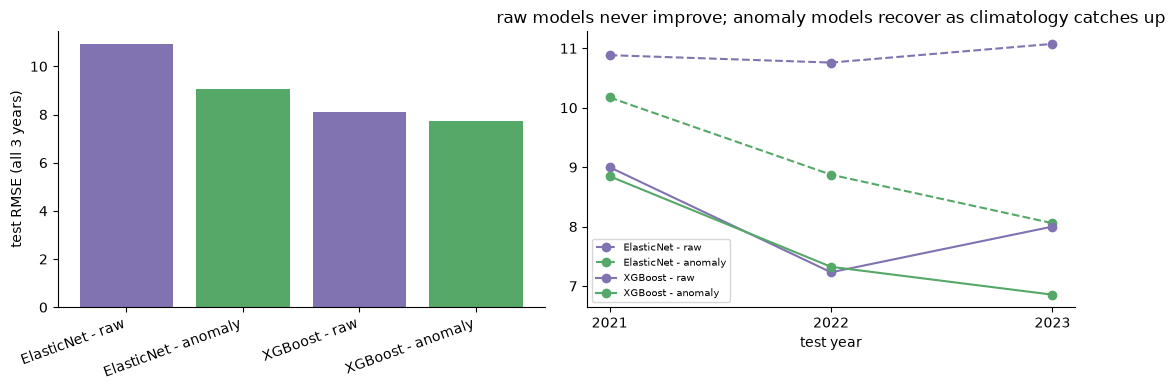

In [5]:
test_pred = test.copy()
for name, (model, cols) in models.items():
    test_pred[name] = model.predict(test[cols])

overall = pd.Series({name: mean_squared_error(test["price"], test_pred[name]) ** 0.5 for name in models}, name="RMSE")
yearly = test_pred.groupby("year").apply(lambda g: pd.Series({n: mean_squared_error(g["price"], g[n]) ** 0.5 for n in models}))
print(overall.round(2))
print(yearly.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(overall.index, overall.values, color=[PURPLE, GREEN, PURPLE, GREEN])
axes[0].set_ylabel("test RMSE (all 3 years)")
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right")
styles = {"ElasticNet - raw": (PURPLE, "--"), "ElasticNet - anomaly": (GREEN, "--"),
          "XGBoost - raw": (PURPLE, "-"), "XGBoost - anomaly": (GREEN, "-")}
for name in models:
    color, ls = styles[name]
    axes[1].plot(yearly.index, yearly[name], marker="o", color=color, ls=ls, label=name)
axes[1].set_xticks(yearly.index)
axes[1].set_xlabel("test year")
axes[1].set_title("raw models never improve; anomaly models recover as climatology catches up")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

## Two questions before trusting this

**Does more training data close the gap?** No — sweep training-set length from 2 to 40 years
and the raw model's error is flat throughout; it's a bias problem (frozen coefficients answer
the wrong question), not a variance problem that more data would fix.

**Does it only matter when hydro is strongly seasonal?** Yes, and it should: sweep hydro's
seasonal amplitude from 0 up, and the raw-vs-anomaly gap grows with it. At zero (hydro has no
seasonal cycle at all) the anomaly feature is a pure cost — decorrelating something that was
never entangled just adds climatology noise.

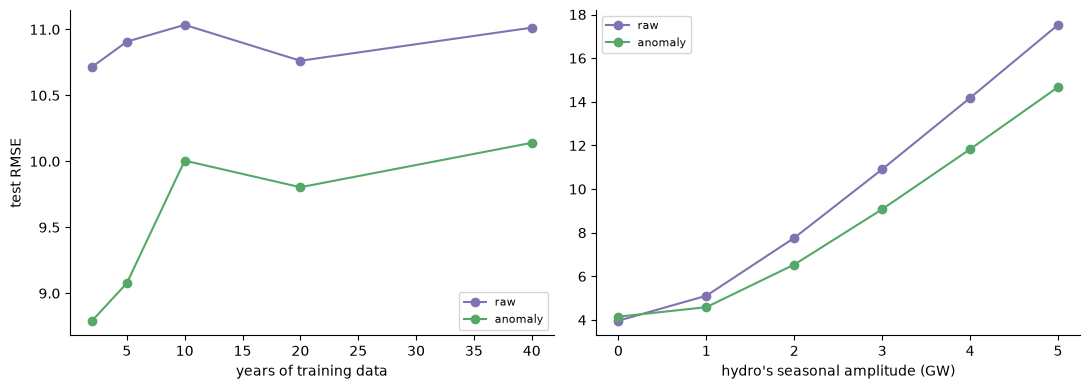

In [6]:
def run_once(train_years=None, hydro_amp=3.0, seed=0):
    ty = train_years if train_years is not None else train_years_default
    rng = np.random.default_rng(seed)
    ny = burn_in_years + ty + 3
    nd = int(ny * 365.25)
    dt = pd.date_range("2000-01-01", periods=nd, freq="D")
    tt = (dt - dt[0]).days / 365.25
    sy = burn_in_years + ty
    sm = tt >= sy
    dem = 12 * np.sin(2 * np.pi * tt) + 6 * np.cos(2 * np.pi * tt)
    ph = np.where(sm, phase_post, phase_pre)
    hs = hydro_amp * np.sin(2 * np.pi * (tt + ph))
    ha = np.empty(nd); ha[0] = 0.0
    iv = rng.normal(0, sigma_innov, nd)
    for i in range(1, nd):
        ha[i] = rho * ha[i - 1] + iv[i]
    hg = 6 + hs + ha + rng.normal(0, 0.2, nd)
    pr = intercept + dem + beta_anom * ha + rng.normal(0, sigma_y, nd)
    d = pd.DataFrame({"t_years": tt, "hydro_gw": hg, "price": pr}, index=dt)
    d["doy"], d["year"] = d.index.dayofyear, d.index.year
    for i in [1, 2]:
        d[f"sin{i}"] = np.sin(2 * np.pi * i * d["t_years"]); d[f"cos{i}"] = np.cos(2 * np.pi * i * d["t_years"])
    d = build_anomaly_feature(d)
    tr = d[(d["t_years"] >= burn_in_years) & (d["t_years"] < sy)]
    te = d[d["t_years"] >= sy]
    er, ea = fit_enet(tr, features_raw), fit_enet(tr, features_anom)
    return (mean_squared_error(te["price"], er.predict(te[features_raw])) ** 0.5,
            mean_squared_error(te["price"], ea.predict(te[features_anom])) ** 0.5)

train_years_default = train_years
data_sweep = pd.DataFrame([{"train_years": ty, "raw": r, "anomaly": a}
                            for ty in [2, 5, 10, 20, 40] for r, a in [run_once(train_years=ty)]])
amp_sweep = pd.DataFrame([{"amp": amp, "raw": r, "anomaly": a}
                           for amp in [0, 1, 2, 3, 4, 5] for r, a in [run_once(hydro_amp=amp)]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(data_sweep["train_years"], data_sweep["raw"], "o-", color=PURPLE, label="raw")
axes[0].plot(data_sweep["train_years"], data_sweep["anomaly"], "o-", color=GREEN, label="anomaly")
axes[0].set_xlabel("years of training data"); axes[0].set_ylabel("test RMSE"); axes[0].legend(fontsize=8)
axes[1].plot(amp_sweep["amp"], amp_sweep["raw"], "o-", color=PURPLE, label="raw")
axes[1].plot(amp_sweep["amp"], amp_sweep["anomaly"], "o-", color=GREEN, label="anomaly")
axes[1].set_xlabel("hydro's seasonal amplitude (GW)"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Conclusion

`X`'s own effect is recovered fine by both parametrizations — the damage from concurvity is not
"the coefficient is biased," it's "the seasonality coefficients silently mean something
different than they look like they mean." That's invisible until the regime the raw model was
calibrated to no longer holds, at which point no amount of pre-shift data saves it, and only a
retrain fixes it. The anomaly model pays no such price and, because its climatology is a cheap,
separately-refreshable statistic, recovers on its own as new data arrives — provided hydro
actually has a seasonal cycle worth separating out in the first place.